In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob
import json
import matplotlib as mpl
mpl.rcParams["font.family"] = "monospace"

from plotting import plot_model_comparison

/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
dataset_name = "crc" # Options: merfish, crc

In [5]:
corr_dir = f"/data2/a330d/datasets/{dataset_name}/correlations"
pattern = os.path.join(corr_dir, "*.json")
files = sorted(glob.glob(pattern))

rows = []
for fp in files:
    name = os.path.basename(fp)
    core = name[len("crc_"):-len(".json")] if dataset_name == "crc" else name[:-len(".json")]
    parts = core.split("_")
    sid = parts[0]
    model_name = parts[1]
    holdout_celltype = "_".join(parts[2:])
    try:
        with open(fp, "r") as f:
            data = json.load(f)
    except Exception:
        # skip unreadable/invalid json
        continue

    try:
        rows.append({
            "sid": f"crc_{sid}" if dataset_name == "crc" else sid,
            "model_name": model_name,
            "holdout_celltype": holdout_celltype,
            "n_deg": data.get("n_deg"),
            "spearman": data.get("spearman"),
            "pearson": data.get("pearson"),
            "precision": data.get("precision"),
            "direction_match": data.get("direction_match"),
            "direction_match_k": data.get("direction_match_k"),
            "mixing_index": data.get("mixing_index"),
            "edistance_global": data.get("edistance_global"),
            "edistance_local": data.get("edistance_local"),            
            "rmse": data.get("rmse"),
        })
    except Exception as e:
        print(f"Error processing file {fp}: {e}")
        continue

data_df = pd.DataFrame(rows)
data_df.head()

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,direction_match_k,mixing_index,edistance_global,edistance_local,rmse
0,crc_120,baseline-cf,Endothelial_CRC,200,0.503041,0.383371,0.170,0.970588,0.165,0.547060,23.927378,25.730283,13188.815073
1,crc_120,baseline-cf,Epithelial_CRC,200,0.129327,0.227521,0.415,0.578313,0.240,0.895650,22.045196,17.380554,546598.415842
2,crc_120,baseline-cf,Fibroblast_CRC,200,0.120677,0.202228,0.135,0.888889,0.120,0.605086,19.173983,21.201362,109470.811764
3,crc_120,baseline-cf,Myeloid_CRC,200,0.246870,0.323619,0.165,0.818182,0.135,0.502754,22.510635,24.561290,29706.071274
4,crc_120,baseline-cf,T_cell_CRC,200,0.676416,0.516258,0.255,0.862745,0.220,0.797638,29.482318,31.280952,14626.556810


In [6]:
# Remove -cf from the end of each model_name
data_df["model_name"] = data_df["model_name"].str.replace("-cf", "", regex=False)
n_deg = data_df["n_deg"].iloc[0]
data_df.head()

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,direction_match_k,mixing_index,edistance_global,edistance_local,rmse
0,crc_120,baseline,Endothelial_CRC,200,0.503041,0.383371,0.170,0.970588,0.165,0.547060,23.927378,25.730283,13188.815073
1,crc_120,baseline,Epithelial_CRC,200,0.129327,0.227521,0.415,0.578313,0.240,0.895650,22.045196,17.380554,546598.415842
2,crc_120,baseline,Fibroblast_CRC,200,0.120677,0.202228,0.135,0.888889,0.120,0.605086,19.173983,21.201362,109470.811764
3,crc_120,baseline,Myeloid_CRC,200,0.246870,0.323619,0.165,0.818182,0.135,0.502754,22.510635,24.561290,29706.071274
4,crc_120,baseline,T_cell_CRC,200,0.676416,0.516258,0.255,0.862745,0.220,0.797638,29.482318,31.280952,14626.556810


In [7]:
df = data_df.copy() # start with existing dataframe
df["sid"] = df["sid"].astype(str)

In [11]:
def unify_formatting(df_parent, df_child):
    df_child["holdout_celltype"] = df_child["holdout_celltype"] + "_" + df_child["target_domain"]
    df_child["sid"] = df_child["sid"].astype(str)

    common_cols = df_parent.columns
    df_child_trimmed = df_child[common_cols.intersection(df_child.columns)]
    combined = pd.concat([df_parent, df_child_trimmed], axis=0, ignore_index=True)

    return combined

In [12]:
# Load mintflow results
mintflow_base_path = f"/data/a330d/projects/cellina-reproducibility-worktrees/major-loo/results/mintflow_{dataset_name}"
mintflow_df = pd.DataFrame()

# Loop over mintflow_base_path and read each file, concatenate into mintflow_df
for file in glob.glob(f"{mintflow_base_path}/mintflow_*.csv"):
    temp_df = pd.read_csv(file)
    mintflow_df = pd.concat([mintflow_df, temp_df], ignore_index=True)
mintflow_df.head()

,dataset_name,sid,control_domain,target_domain,n_deg,model_name,holdout_celltype,spearman,pearson,precision,direction_match,direction_match_k,mixing_index,edistance_global,edistance_local,rmse
0,crc,crc_221,REF,CRC,200,mintflow,Endothelial,0.926473,0.994751,0.610,1.000000,0.610,0.618875,19.922754,23.093698,16807.797452
1,crc,crc_221,REF,CRC,200,mintflow,Epithelial,0.737813,0.675139,0.220,0.954545,0.210,0.731114,21.671429,23.203575,212237.136958
2,crc,crc_221,REF,CRC,200,mintflow,Fibroblast,0.516073,0.675582,0.260,0.942308,0.245,0.443372,24.507703,27.523380,93643.451952
3,crc,crc_221,REF,CRC,200,mintflow,Myeloid,0.942205,0.996283,0.695,1.000000,0.695,0.341953,20.822433,24.066744,23529.663687
4,crc,crc_221,REF,CRC,200,mintflow,T_cell,0.817999,0.851127,0.420,0.976190,0.410,0.792914,27.299629,30.694458,31114.001223


In [14]:
combined_df = unify_formatting(df, mintflow_df)

In [15]:
spprop_csv_path = f'../results/loo_spatialprop_{dataset_name}_DEG_{int(n_deg)}.csv'
spprop_df = pd.read_csv(spprop_csv_path)
spprop_df.head()

,dataset_name,sid,control_domain,target_domain,n_deg,model_name,holdout_celltype,spearman,pearson,precision,direction_match,direction_match_k,mixing_index,edistance_global,edistance_local,rmse,top_n_perturb
0,crc,crc_242,REF,CRC,200,spatialprop,Endothelial,0.501977,0.658754,0.135,1.000000,0.135,0.999391,14.858295,20.016422,2810.3518,2000
1,crc,crc_242,REF,CRC,200,spatialprop,Epithelial,0.277664,0.211048,0.080,0.875000,0.070,0.915537,8.331620,13.984996,42163.5080,2000
2,crc,crc_242,REF,CRC,200,spatialprop,Fibroblast,0.278066,0.385074,0.095,0.947368,0.090,0.792931,8.768958,16.650926,32901.6050,2000
3,crc,crc_242,REF,CRC,200,spatialprop,Myeloid,0.412606,0.640395,0.120,0.875000,0.105,0.894623,17.144410,20.466875,7849.5474,2000
4,crc,crc_242,REF,CRC,200,spatialprop,T_cell,0.605075,0.719364,0.130,0.961538,0.125,0.783667,20.860390,26.056180,6610.0444,2000


In [16]:
combined_df = unify_formatting(combined_df, spprop_df)

In [17]:
grouping = "holdout_celltype"

# Define order
model_order = [
    "baseline",
    "mintflow",
    "spatialprop",
    "cpa",
    "scgen",
    "cellina-ablated",
    "cellina-graph",
    "cellina",
]

default_palette = 'colorblind'
palette = default_palette

In [18]:
# Base palette (colorblind-friendly)
base_colors = sns.color_palette(default_palette, n_colors=len(model_order))

# Convert to dict mapped by model name
palette_dict = dict(zip(model_order, base_colors))

# Create a red gradient for the 3 cellina models
cellina_reds = sns.color_palette("Reds", 5)[1:] 

# skip the lightest so it's still visible
palette_dict["cellina-ablated"] = cellina_reds[1]
palette_dict["cellina-graph"]   = cellina_reds[2]
palette_dict["cellina"]         = cellina_reds[3]

# non-spatial green
palette_dict["mintflow"]   = sns.color_palette("Greens", 4)[1]
palette_dict["scgen"]   = sns.color_palette("Greens", 4)[2]
palette_dict["cpa"] = sns.color_palette("Greens", 4)[3]
palette_dict["spatialprop"]   = sns.color_palette("Greens", 4)[0]

palette = palette_dict

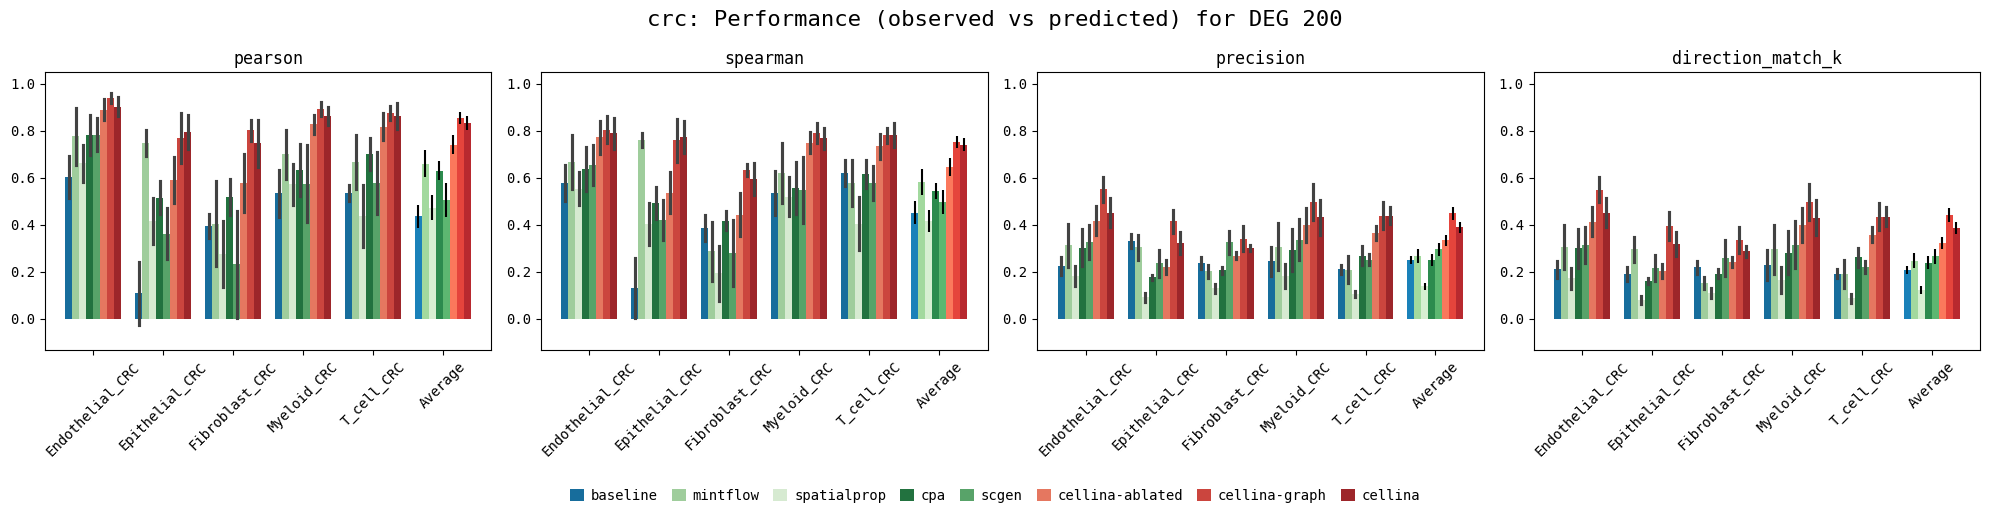

In [19]:
metrics = ["pearson", "spearman", "precision", "direction_match_k"]
plot_model_comparison(
    dataset_name,
    combined_df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=False,
    save_name=f"ood_summary_correlations_{dataset_name}_{n_deg}"
)

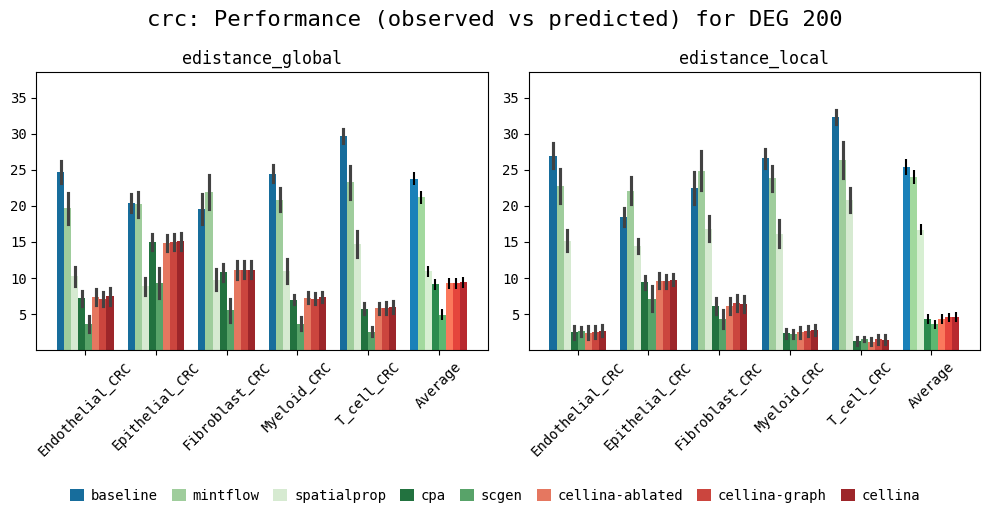

In [20]:
metrics = ["edistance_global", "edistance_local"]
plot_model_comparison(
    dataset_name,
    combined_df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=False,
    save_name=f"ood_summary_correlations_{dataset_name}_{n_deg}"
)

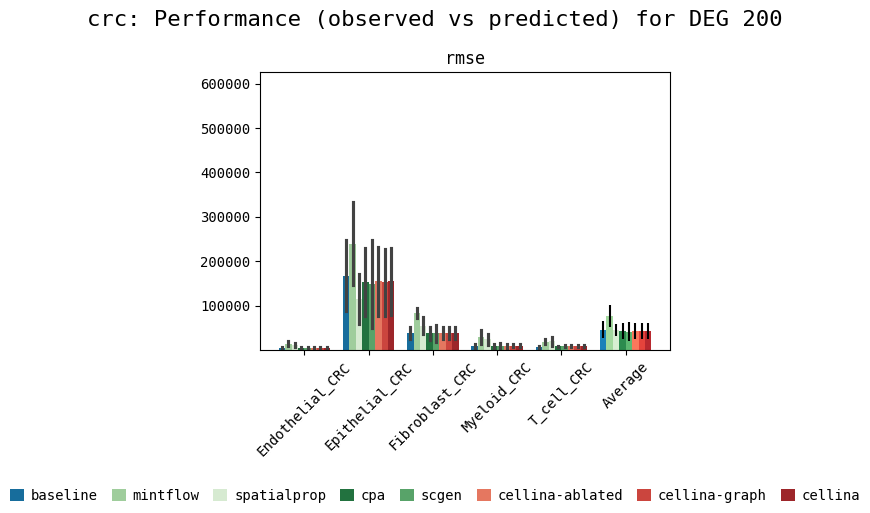

In [21]:
metrics = ["rmse"]
plot_model_comparison(
    dataset_name,
    combined_df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=False,
    save_name=f"ood_summary_correlations_{dataset_name}_{n_deg}"
)

In [22]:
combined_df.to_csv(f"../results/loo_summary_{dataset_name}_DEG_{n_deg}.csv", index=False)